In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Sklearn - evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')
print(f"Data shape: {df.shape}")
df.head()

Data shape: (499290, 257)


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,Airport_Code,Weather_Timestamp,...,Astronomical_Twilight_night,Astronomical_Twilight_nan,weather_group_clear,weather_group_cloudy,weather_group_low_visibility,weather_group_other,weather_group_rain,weather_group_snow_ice,weather_group_storm,weather_group_nan
0,2,2019-10-29 13:16:54,2019-10-29 15:21:34,35.834797,-78.638512,0.000,5574,7666,6971,2019-10-29 12:51:00,...,False,False,False,True,False,False,False,False,False,False
1,2,2021-10-13 06:30:00,2021-10-13 06:59:15,36.088970,-96.011734,0.000,1896,1928,966,2021-10-13 06:29:00,...,False,False,False,False,False,False,True,False,False,False
2,2,2022-08-14 14:42:58,2022-08-14 16:27:58,33.537049,-86.794445,0.152,1143,3805,1434,2022-08-14 14:53:00,...,False,False,True,False,False,False,False,False,False,False
3,2,2021-06-25 19:13:44,2021-06-25 20:42:30,34.071722,-117.612886,0.869,1208,7010,2253,2021-06-25 18:53:00,...,False,False,True,False,False,False,False,False,False,False
4,2,2022-03-18 12:50:30,2022-03-18 13:13:00,40.324235,-76.790464,0.166,324,418,801,2022-03-18 12:56:00,...,False,False,True,False,False,False,False,False,False,False


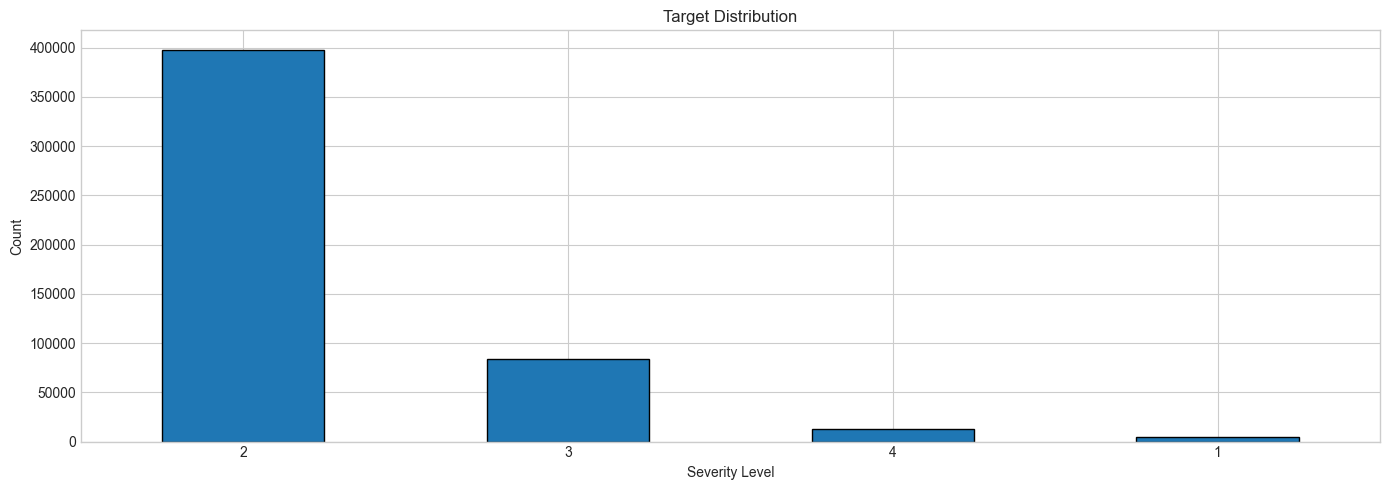

In [4]:
# Visualize the binned distribution
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Binned category counts
df['Target'].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Count')
ax.set_title('Target Distribution')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [5]:
# Check class balance
class_counts = df['Target'].value_counts()
class_percentages = df['Target'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
2: 397669 (79.6%)
3: 84039 (16.8%)
4: 13229 (2.6%)
1: 4353 (0.9%)

Consider adjusting your binning strategy.


In [6]:
#400,000 rows with 252 features take a very long time to train

# for testing, manually create a balanced 20,000 rows dataset

df_sample = df.groupby('Target', group_keys=False)\
              .apply(lambda x: x.sample(n=min(len(x), 4000), random_state=42))\
              .reset_index(drop=True)

In [7]:
df_sample.shape

(16000, 257)

In [8]:
df_sample['Target'].value_counts()

Target
1    4000
2    4000
3    4000
4    4000
Name: count, dtype: int64

In [9]:
#df = df_sample

In [10]:
datetime_cols = df.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns

print(datetime_cols)

Index([], dtype='object')


In [11]:
time_cols = df.columns[df.columns.str.contains('time', case=False)]

print(time_cols)

Index(['Start_Time', 'End_Time', 'Weather_Timestamp', 'Timezone_missing',
       'Timezone_us/central', 'Timezone_us/eastern', 'Timezone_us/mountain',
       'Timezone_us/pacific', 'Timezone_nan'],
      dtype='object')


In [12]:
X = df.drop(columns=['Severity', 'Target', 'Start_Time', 'End_Time', 'Weather_Timestamp']).copy()
y = df['Target']

In [13]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (499290, 252)
Target shape: (499290,)

Features used: ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'City', 'County', 'Airport_Code', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'duration_min', 'is_freezing', 'low_visibility', 'lat_bin', 'n_road_features', 'has_traffic_control', 'State_al', 'State_ar', 'State_az', 'State_ca', 'State_co', 'State_ct', 'State_dc', 'State_de', 'State_fl', 'State_ga', 'State_ia', 'State_id', 'State_il', 'State_in', 'State_ks', 'State_ky', 'State_la', 'State_ma', 'State_md', 'State_me', 'State_mi', 'State_mn', 'State_mo', 'State_ms', 'State_mt', 'State_nc', 'State_nd', 'State_ne', 'State_nh', 'State_nj', 'Sta

In [14]:
# TODO: Encode your target labels to numbers using LabelEncoder
#
# Steps:
# 1. Create a LabelEncoder instance
# 2. Fit and transform y to create y_encoded
#
# Hint: label_encoder.fit_transform(y)

# YOUR CODE HERE:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [15]:
# TODO: Split your data with stratification
#
# Requirements:
# - 80/20 split (test_size=0.2)
# - random_state=42 for reproducibility
# - stratify=y_encoded (THIS IS THE KEY DIFFERENCE FROM REGRESSION!)
#   This ensures each class is proportionally represented in train/test
#
# Store in: X_train, X_test, y_train, y_test

# YOUR CODE HERE:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=0.2, # 30% of data for testing
    random_state=42, # for reproducibility
    stratify=y_encoded # this is the key parameter for stratification
)

In [16]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(28.670111972437553), np.int64(1): np.float64(0.3138856145975765), np.int64(2): np.float64(1.4852969612232452), np.int64(3): np.float64(9.435698762165737)}


In [17]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f" {c} ({c/len(y_train)*100:.1f}%)")

Training set: 399432 samples
Test set: 99858 samples

Training class distribution:
 3483 (0.9%)
 318135 (79.6%)
 67231 (16.8%)
 10583 (2.6%)


In [18]:
# TODO: Scale your features using StandardScaler
#
# Same as regression:
# 1. Create StandardScaler instance
# 2. fit_transform on X_train
# 3. transform (only!) on X_test
#
# Store in: X_train_scaled, X_test_scaled

# YOUR CODE HERE:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
# Convert to DataFrame (helpful for later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

SELECTED_FEATURES = X.columns.tolist()
print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 252 features.


In [20]:
#!pip install xgboost

In [21]:

# Cross-validation for key models
# This also serves as an early model comparator

print("5-Fold Cross-Validation Results")
print("=" * 50)

models_to_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

cv_results = []
for name, model in models_to_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std': scores.std()
    })
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)
cv_df


5-Fold Cross-Validation Results


KeyboardInterrupt: 

In [ ]:
# xgbclassifier clearly out-performs the other two models
# use xgboost to build and evaluate key matrics

from xgboost import XGBClassifier

gb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    random_state=42,
    objective='multi:softprob',
    num_class=4,
    scale_pos_weight=class_weights  # per class tuning
)

gb_model_name = 'Gradient Boosting'

gb_model.fit(X_train_scaled, y_train)

#gb_results, gb_trained, gb_preds = evaluate_classifier(gb_model, X_train_scaled, X_test_scaled, 
#                                                                         y_train, y_test, gb_model_name)

# Print results
#print(f"Gradient Boosting - Test Accuracy: {gb_results['Test Accuracy']:.4f}, F1: {gb_results['F1 (weighted)']:.4f}")

In [ ]:
y_train_pred = gb_model.predict(X_train_scaled)
y_test_pred = gb_model.predict(X_test_scaled)

In [ ]:
print (f"'Train Accuracy': {accuracy_score(y_train, y_train_pred):.4f}")

In [ ]:
print (f"'Test Accuracy': {accuracy_score(y_test, y_test_pred):.4f}")

In [ ]:
print (f"'Precision (weighted)': {precision_score(y_test, y_test_pred, average='weighted'):.4f}")

In [ ]:
print (f"'Recall (weighted)': {recall_score(y_test, y_test_pred, average='weighted'):.4f}")

In [ ]:
print (f"'F1 (weighted)': {f1_score(y_test, y_test_pred, average='weighted'):.4f}")